# Part 2 : Implementation and Analysis of Collision-Triggered Bi-Greedy Probing

**Data Structures & Algorithms Module Assignment, Part 2 (high-level demonstration)**

This notebook implements the algorithm proposed in the Part 1 report (*Addressing High-Load
Collision Costs in In-Memory Key-Value Stores through Collision-Triggered Bi-Greedy Probing*)
and carries out the work Part 2 requires: a working implementation, test cases, an empirical and
analytical determination of computational complexity, and an optimisation pass. The notebook is
organised as follows.

1. Basic Python implementation: a direct, readable translation of the Part 1 pseudocode
   into object-oriented Python, plus a classical linear-probing baseline.
2. Test cases: differential testing against Python's built-in `dict`/`set`, duplicate and
   negative-lookup behaviour, full-table and resize edge cases, and the stability invariant.
3. Computational Complexity Analysis: the methodology (analytic reasoning plus two empirical
   techniques: input doubling and log–log slope fitting), followed by the experiments.
4. CPython-optimised version: the same algorithm rewritten with CPython-specific
   techniques, verified to be behaviourally identical, and benchmarked.
5. C++ implementations (as reference text): an object-oriented C++ version matching the
   class design promised in Part 1 (5.6), and a suggested optimised C++ version.
6. Suggested optimised C++ implementation (reference text)   
7. Implications for the Real-World Problem
8. GenAI Usage
9. References


The complete Python and C++ source code, including the OOP and optimised reference implementations, is available in the project repository [8]

## 1. Basic Python implementation

Algorithm recap (from Part 1, Section 5):
Every operation runs in two phases over a single slot array of capacity *n* (for stability, no deletions)

- Phase 1 : bounded local window.

  Scan `L` consecutive slots from the key's home position.
  An empty slot resolves the operation immediately (insertion places there; a lookup gains a
  *free absence certificate*). Finding the key resolves it too.

- Trigger: If all `L` slots are occupied without resolution, the operation has locally
  observed congestion and escalates. Because slots never vacate, a key whose window was full at
  insertion time finds it full at every later lookup, so the two regimes never disagree about
  which one owns a key.

- Phase 2 : staged bi-greedy fallback.

  The array is partitioned into regions
  `R1..Rk` (geometrically shrinking, with `Rk` taking the remainder so the regions cover
  everything). Insertions walk a *balanced* schedule (early budget in the large regions);
  triggered lookups walk an *imbalanced* query schedule interleaved, in order, with the
  insertion schedule, so that the first empty slot met **on the insertion path** certifies
  absence. Probe positions within a region are a pure function of `(key, region, t)`, shared by
  both schedules.

The classes below follow that structure directly: a mixing function, an `Outcome` enum, a
`ProbeStatistics` collaborator, the region partition, the two schedule objects, and the table
itself.

Note: Python is used here for clarity of demonstration; probe counts (the quantity the complexity analysis is about) are language-independent, while wall-clock speed is where the C++ implementations at the end become relevant.

In [ ]:
from enum import Enum

MASK64 = (1 << 64) - 1


def mix64(x):
    """splitmix64 finaliser: a fast, well-distributed 64-bit mixing function."""
    x = (x + 0x9E3779B97F4A7C15) & MASK64
    x = ((x ^ (x >> 30)) * 0xBF58476D1CE4E5B9) & MASK64
    x = ((x ^ (x >> 27)) * 0x94D049BB133111EB) & MASK64
    return (x ^ (x >> 31)) & MASK64


class Outcome(Enum):
    FOUND = "FOUND"
    ABSENT = "ABSENT"
    OK = "OK"
    DUPLICATE = "DUPLICATE"
    FULL = "FULL"


class ProbeStatistics:
    """Small collaborator that aggregates probe counts per operation kind."""

    def __init__(self):
        self.reset()

    def reset(self):
        self._sum = {}
        self._cnt = {}
        self.triggers = 0
        self.ops = 0

    def record(self, kind, probes):
        self._sum[kind] = self._sum.get(kind, 0) + probes
        self._cnt[kind] = self._cnt.get(kind, 0) + 1
        self.ops += 1

    def avg(self, kind):
        c = self._cnt.get(kind, 0)
        return self._sum.get(kind, 0) / c if c else 0.0

    def count(self, kind):
        return self._cnt.get(kind, 0)

In [ ]:
class RegionPartition:
    """Disjoint partition of [0, n): geometrically shrinking regions, remainder to the last."""

    def __init__(self, n, k):
        self.k = k
        self.bounds = []          # list of (start, size)
        start = 0
        for i in range(1, k):
            size = max(1, n >> i)          # n/2, n/4, ...
            size = min(size, n - start - (k - i))  # leave room for later regions
            self.bounds.append((start, size))
            start += size
        self.bounds.append((start, n - start))     # R_k takes the remainder
        assert sum(s for _, s in self.bounds) == n

    def __getitem__(self, i):                       # 1-indexed regions
        return self.bounds[i - 1]


class InsertionSchedule:
    """Balanced: stage s spends c*2^(s-i) probes in region i (early, large regions favoured)."""

    def __init__(self, c=1, s_max=6):
        self.c, self.s_max = c, s_max

    def steps(self, k):
        for s in range(1, self.s_max + 1):
            for i in range(1, min(s, k) + 1):
                yield i, self.c * (1 << (s - i))


class QuerySchedule:
    """Imbalanced: stage s spends c*2^(s-j) probes in each of R_1..R_{4^(j-1)} (late regions early)."""

    def __init__(self, c=1, s_max=6):
        self.c, self.s_max = c, s_max

    def steps(self, k):
        for s in range(1, self.s_max + 1):
            for j in range(1, s + 1):
                reach = min(4 ** (j - 1), k)
                for i in range(1, reach + 1):
                    yield i, self.c * (1 << (s - j))

### The table class

`insert` and `lookup` share Phase 1 and the trigger and diverge only in the fallback schedule
they consult, exactly as in the Part 1 pseudocode. Every slot inspection is counted, because
probe counts are the currency of the complexity analysis in Section 3.

In [ ]:
class CTBGHashTable:
    """Collision-triggered bi-greedy open-addressed hash table (stable: no deletions)."""

    def __init__(self, capacity, L=16, c=1, s_max=6, stats=None):
        self.n = capacity
        self.L = L
        self.slots = [None] * capacity          # each slot: None or (key, value)
        self.count = 0
        k = max(2, capacity.bit_length() - 4)   # enough geometric regions for the demo
        self.regions = RegionPartition(capacity, k)
        self.insert_sched = InsertionSchedule(c, s_max)
        self.query_sched = QuerySchedule(c, s_max)
        self.stats = stats if stats is not None else ProbeStatistics()

    # shared synchronised probe positions
    def _home(self, key):
        return mix64(hash(key)) % self.n

    def _probe_pos(self, key, region_i, t):
        start, size = self.regions[region_i]
        h = mix64(hash(key) ^ (region_i * 0xC2B2AE3D27D4EB4F) ^ (t * 0x165667B19E3779F9))
        return start + h % size

    # probe streams
    def _insert_path(self, key):
        """Positions in insertion order: staged walk, then terminal reversed scan."""
        counters = {}
        for i, budget in self.insert_sched.steps(self.regions.k):
            t = counters.get(i, 0)
            for _ in range(budget):
                yield self._probe_pos(key, i, t)
                t += 1
            counters[i] = t
        for pos in range(self.n - 1, -1, -1):       # terminal stage: full coverage
            yield pos

    def _query_path(self, key):
        counters = {}
        for i, budget in self.query_sched.steps(self.regions.k):
            t = counters.get(i, 0)
            for _ in range(budget):
                yield self._probe_pos(key, i, t)
                t += 1
            counters[i] = t

    # operations
    def insert(self, key, value):
        slots, n, L = self.slots, self.n, self.L
        home = self._home(key)
        probes = 0
        for j in range(L):                          # Phase 1: bounded local window
            pos = (home + j) % n
            probes += 1
            s = slots[pos]
            if s is None:
                slots[pos] = (key, value)
                self.count += 1
                self.stats.record("insert_local", probes)
                return Outcome.OK
            if s[0] == key:
                self.stats.record("insert_dup", probes)
                return Outcome.DUPLICATE
        self.stats.triggers += 1                    # Trigger: window full
        for pos in self._insert_path(key):          # Phase 2: staged bi-greedy walk
            probes += 1
            s = slots[pos]
            if s is None:
                slots[pos] = (key, value)
                self.count += 1
                self.stats.record("insert_fallback", probes)
                return Outcome.OK
            if s[0] == key:
                self.stats.record("insert_dup", probes)
                return Outcome.DUPLICATE
        self.stats.record("insert_full", probes)
        return Outcome.FULL

    def lookup(self, key):
        slots, n, L = self.slots, self.n, self.L
        home = self._home(key)
        probes = 0
        for j in range(L):                          # Phase 1
            pos = (home + j) % n
            probes += 1
            s = slots[pos]
            if s is None:                           # free absence certificate
                self.stats.record("lookup_miss_local", probes)
                return Outcome.ABSENT
            if s[0] == key:
                self.stats.record("lookup_hit_local", probes)
                return Outcome.FOUND
        self.stats.triggers += 1                    # Trigger
        ins, qry = self._insert_path(key), self._query_path(key)
        ins_alive = qry_alive = True
        while ins_alive or qry_alive:               # Phase 2: interleaved walk
            if ins_alive:
                try:
                    pos = next(ins)
                    probes += 1
                    s = slots[pos]
                    if s is None:                   # empty on the insertion path
                        self.stats.record("lookup_miss_fb", probes)
                        return Outcome.ABSENT
                    if s[0] == key:
                        self.stats.record("lookup_hit_fb", probes)
                        return Outcome.FOUND
                except StopIteration:
                    ins_alive = False
            if qry_alive:
                try:
                    pos = next(qry)
                    probes += 1
                    s = slots[pos]
                    if s is not None and s[0] == key:
                        self.stats.record("lookup_hit_fb", probes)
                        return Outcome.FOUND
                    # an empty slot on a query-only probe certifies nothing
                except StopIteration:
                    qry_alive = False
        self.stats.record("lookup_miss_fb", probes)  # table 100% full, key nowhere
        return Outcome.ABSENT

    def resize(self, new_capacity=None):
        old = [s for s in self.slots if s is not None]
        self.__init__(new_capacity or self.n * 2, self.L,
                      self.insert_sched.c, self.insert_sched.s_max, self.stats)
        for k_, v_ in old:
            assert self.insert(k_, v_) is Outcome.OK

    @property
    def load(self):
        return self.count / self.n

### Baseline: classical linear probing

The comparison partner for the experiments, instrumented identically.

In [ ]:
class LinearProbingTable:
    """Classical linear probing baseline with identical instrumentation."""

    def __init__(self, capacity, stats=None):
        self.n = capacity
        self.slots = [None] * capacity
        self.count = 0
        self.stats = stats if stats is not None else ProbeStatistics()

    def _home(self, key):
        return mix64(hash(key)) % self.n

    def insert(self, key, value):
        slots, n = self.slots, self.n
        pos = self._home(key)
        for probes in range(1, n + 1):
            s = slots[pos]
            if s is None:
                slots[pos] = (key, value)
                self.count += 1
                self.stats.record("insert", probes)
                return Outcome.OK
            if s[0] == key:
                self.stats.record("insert_dup", probes)
                return Outcome.DUPLICATE
            pos = (pos + 1) % n
        self.stats.record("insert_full", n)
        return Outcome.FULL

    def lookup(self, key):
        slots, n = self.slots, self.n
        pos = self._home(key)
        for probes in range(1, n + 1):
            s = slots[pos]
            if s is None:
                self.stats.record("lookup_miss", probes)
                return Outcome.ABSENT
            if s[0] == key:
                self.stats.record("lookup_hit", probes)
                return Outcome.FOUND
            pos = (pos + 1) % n
        self.stats.record("lookup_miss", n)
        return Outcome.ABSENT

    @property
    def load(self):
        return self.count / self.n

## 2. Test cases

Correctness is established by **differential testing**: the table is driven with the same
operations as a Python `dict` (the reference implementation), and every outcome must agree.
This catches placement bugs, broken absence certificates, and duplicate mishandling in one
sweep, and it is the debugging technique that was used while developing the code and when when a probe
formula was wrong, the first disagreeing key immediately localised the fault. The suite also
covers the edge cases the design's correctness argument leans on:

- duplicates are detected in **both** phases (window hit, and fallback re-walk of the identical
  insertion path);
- negative lookups are certified absent in both phases (window empty slot, and empty slot on
  the interleaved insertion path);
- a **100% full** table still terminates and answers absent lookups correctly (terminal stage);
- `resize` preserves every stored pair;
- the **stability invariant** holds (occupied slots never vacate), which is what both absence
  certificates rely on.

In [ ]:
import random

def test_differential(n=1 << 13, load=0.95, n_lookups=2000, seed=42):
    """Outcomes must agree with dict/set for inserts, duplicates, hits and misses."""
    random.seed(seed)
    t, ref = CTBGHashTable(n, L=16), {}
    keys = random.sample(range(1, 10**9), int(n * load))
    for k in keys:
        assert t.insert(k, 2 * k) is Outcome.OK
        ref[k] = 2 * k
    for k in random.sample(keys, 300):                       # duplicates
        assert t.insert(k, 0) is Outcome.DUPLICATE and k in ref
    for k in random.sample(keys, n_lookups):                 # hits
        assert t.lookup(k) is Outcome.FOUND and k in ref
    for k in random.sample(range(10**9, 2 * 10**9), n_lookups):  # misses
        assert t.lookup(k) is Outcome.ABSENT and k not in ref
    return t

def test_full_table_and_resize():
    """Terminal stage: correct behaviour at 100% load; resize preserves content."""
    t = CTBGHashTable(256, L=8)
    i = 0
    while t.count < 256:
        assert t.insert(10**9 + i, i) is Outcome.OK
        i += 1
    assert t.lookup(5) is Outcome.ABSENT          # absent key, table completely full
    assert t.insert(5, 5) is Outcome.FULL         # no empty slot anywhere
    t.resize(1024)
    assert t.insert(5, 5) is Outcome.OK
    for j in range(i):                            # every old pair survived the rebuild
        assert t.lookup(10**9 + j) is Outcome.FOUND
    assert t.lookup(5) is Outcome.FOUND

def test_trigger_consistency(seed=9):
    """Keys placed by the fallback must be found by later (triggered) lookups."""
    random.seed(seed)
    t = CTBGHashTable(1 << 11, L=8)
    keys = random.sample(range(1, 10**9), int((1 << 11) * 0.98))
    for k in keys:
        assert t.insert(k, k) is Outcome.OK
    fb_before = t.stats.count("insert_fallback")
    assert fb_before > 0, "test should exercise the fallback path"
    for k in keys:
        assert t.lookup(k) is Outcome.FOUND
    return fb_before

def test_stability_invariant(seed=1):
    """No slot ever vacates: the set of occupied positions only grows."""
    random.seed(seed)
    t = CTBGHashTable(1 << 10, L=8)
    occupied = set()
    for k in random.sample(range(1, 10**9), 1000):
        t.insert(k, k)
        now = {i for i, s in enumerate(t.slots) if s is not None}
        assert occupied <= now                    # previous occupancy is preserved
        occupied = now

t = test_differential();        print("PASS  differential vs dict at load", round(t.load, 2))
test_full_table_and_resize();   print("PASS  full-table termination and resize")
nfb = test_trigger_consistency(); print(f"PASS  trigger consistency ({nfb} fallback placements all found)")
test_stability_invariant();     print("PASS  stability invariant")
print("\nAll tests passed.")

PASS  differential vs dict at load 0.95
PASS  full-table termination and resize
PASS  trigger consistency (302 fallback placements all found)
PASS  stability invariant

All tests passed.


## 3. Computational Complexity Analysis

Three complementary techniques are used; the first is analytic, the other two empirical, and the
conclusion is only accepted where they agree.

**(a) Analytic reasoning and count the dominant operation.** The dominant operation is the slot
inspection (one comparison plus one array access), so complexity is expressed in probes.
Reading the code directly:

| Case | Probes | Bound |
|---|---|---|
| Untriggered operation | ≤ `L` window inspections | `O(L)` = **O(1)** for fixed `L` |
| Triggered, staged phase | ≤ `B` = (insert steps + query steps) | `O(B)` = **O(1)** for fixed schedule |
| Triggered, terminal stage | ≤ `n` | **O(n)** worst case |
| Space | `n` slots + `k` region descriptors | **O(n + k) = O(n)** |

The worst case `O(n)` is the honest bound for any open-addressed table near saturation (the
Part 1 report, (5.5), claims nothing stronger). What the analytic table cannot give is the
**expected** cost at a given load (What's to be measured).

**(b) Doubling experiment : dependence on n.** Hold the load factor fixed and double `n`
repeatedly. If average probes per operation stay flat, cost is independent of `n` for that
load; growth would reveal a hidden `n`-dependence.

**(c) Log–log slope fitting : dependence on the load.** Write the load as `1 − δ` and plot
average probes against `δ⁻¹` on log–log axes. A curve `cost ≈ c·δ⁻ᵖ` becomes a straight line
of slope `p`, so fitting the slope estimates the exponent: classical theory predicts slope ≈ 1
for linear-probing hits and ≈ 2 for its misses (Knuth), giving the baseline a known signature
the method must reproduce before its readings for the new algorithm are trusted.

The experiments below use the basic class; Section 4 verifies behavioural equivalence and identical final slot placement.

### Experiment A : doubling n at fixed load (dependence on n)

In [ ]:
import random

def run_workload(cls, n, load, n_lookups=1200, seed=101, L=16):
    random.seed(seed)
    t = cls(n, L=L) if cls is not LinearProbingTable else cls(n)
    keys = random.sample(range(1, 10**9), int(n * load))
    for k in keys:
        t.insert(k, k)
    for k in random.sample(keys, n_lookups):
        t.lookup(k)
    for k in random.sample(range(10**9, 2 * 10**9), n_lookups):
        t.lookup(k)
    return t.stats

print(f"{'n':>7} | {'avg insert':>10} | {'avg hit':>8} | {'avg miss':>9}   (load fixed at 0.90)")
sizes = [1 << 12, 1 << 13, 1 << 14, 1 << 15, 1 << 16]
for n in sizes:
    s = run_workload(CTBGHashTable, n, 0.90)
    ins = (s.avg("insert_local") * s.count("insert_local")
           + s.avg("insert_fallback") * s.count("insert_fallback")) / (
           s.count("insert_local") + s.count("insert_fallback"))
    hit = (s.avg("lookup_hit_local") * s.count("lookup_hit_local")
           + s.avg("lookup_hit_fb") * s.count("lookup_hit_fb")) / (
           s.count("lookup_hit_local") + s.count("lookup_hit_fb"))
    mis = (s.avg("lookup_miss_local") * s.count("lookup_miss_local")
           + s.avg("lookup_miss_fb") * max(1, s.count("lookup_miss_fb"))) / (
           s.count("lookup_miss_local") + s.count("lookup_miss_fb"))
    print(f"{n:>7} | {ins:>10.2f} | {hit:>8.2f} | {mis:>9.2f}")
print("\nFlat columns while n grows 16x  =>  per-operation cost is independent of n at fixed load.")

      n | avg insert |  avg hit |  avg miss   (load fixed at 0.90)
   4096 |       3.57 |     3.62 |     18.96
   8192 |       3.64 |     3.96 |     18.62
  16384 |       3.60 |     4.30 |     18.46
  32768 |       3.55 |     3.83 |     19.09
  65536 |       3.59 |     3.71 |     18.00

Flat columns while n grows 16x  =>  per-operation cost is independent of n at fixed load.


### Experiment B : load sweep against linear probing (dependence on the load)

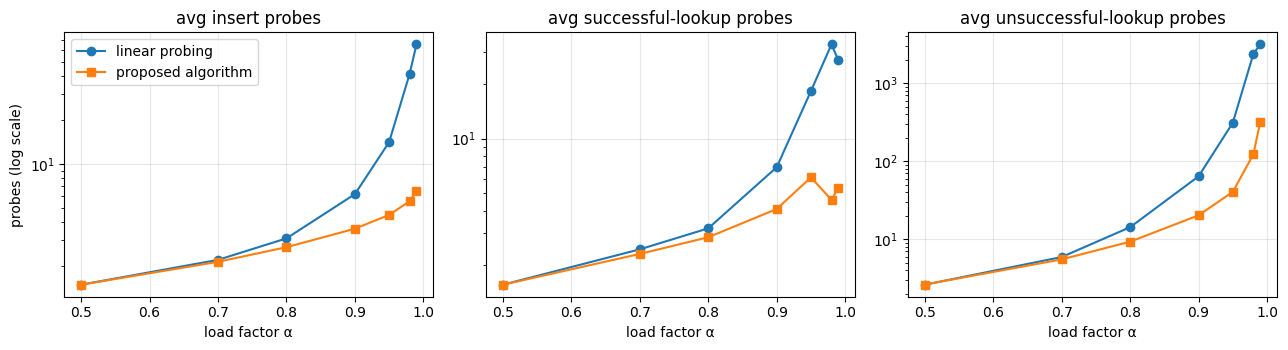

fitted exponent p in cost ~ δ^(-p), using loads ≥ 0.80:
  linear probing   hits p ≈ 0.76   (theory: 1)
  linear probing misses p ≈ 1.90   (theory: 2)
  proposed algo    hits p ≈ 0.17
  proposed algo  misses p ≈ 1.17


In [ ]:
import math
import matplotlib.pyplot as plt

def sweep(cls, loads, n=1 << 14, n_lookups=600, L=16):
    out = []
    for a in loads:
        s = run_workload(cls, n, a, n_lookups=n_lookups, L=L)
        if cls is LinearProbingTable:
            ins, hit, mis = s.avg("insert"), s.avg("lookup_hit"), s.avg("lookup_miss")
        else:
            def wavg(*kinds):
                tot = sum(s.avg(k) * s.count(k) for k in kinds)
                cnt = sum(s.count(k) for k in kinds)
                return tot / cnt if cnt else 0.0
            ins = wavg("insert_local", "insert_fallback")
            hit = wavg("lookup_hit_local", "lookup_hit_fb")
            mis = wavg("lookup_miss_local", "lookup_miss_fb")
        out.append((a, ins, hit, mis))
    return out

loads = [0.50, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99]
ctbg = sweep(CTBGHashTable, loads)
lin  = sweep(LinearProbingTable, loads)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, idx, title in zip(axes, (1, 2, 3), ("avg insert probes", "avg successful-lookup probes",
                                            "avg unsuccessful-lookup probes")):
    ax.plot([r[0] for r in lin],  [r[idx] for r in lin],  "o-", label="linear probing")
    ax.plot([r[0] for r in ctbg], [r[idx] for r in ctbg], "s-", label="proposed algorithm")
    ax.set_xlabel("load factor α"); ax.set_title(title); ax.set_yscale("log"); ax.grid(alpha=.3)
axes[0].set_ylabel("probes (log scale)"); axes[0].legend()
plt.tight_layout(); plt.show()

# log-log slope fit: cost ~ c * (1/δ)^p, δ = 1 - α
def slope(rows, idx, from_load=0.80):
    xs = [math.log(1 / (1 - a)) for a, *_ in rows if a >= from_load]
    ys = [math.log(r[idx]) for r in rows if r[0] >= from_load]
    n = len(xs); mx, my = sum(xs) / n, sum(ys) / n
    return sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / sum((x - mx) ** 2 for x in xs)

print("fitted exponent p in cost ~ δ^(-p), using loads ≥ 0.80:")
print(f"  linear probing   hits p ≈ {slope(lin, 2):.2f}   (theory: 1)")
print(f"  linear probing misses p ≈ {slope(lin, 3):.2f}   (theory: 2)")
print(f"  proposed algo    hits p ≈ {slope(ctbg, 2):.2f}")
print(f"  proposed algo  misses p ≈ {slope(ctbg, 3):.2f}")

### Experiment C : trigger rate against the α^L baseline

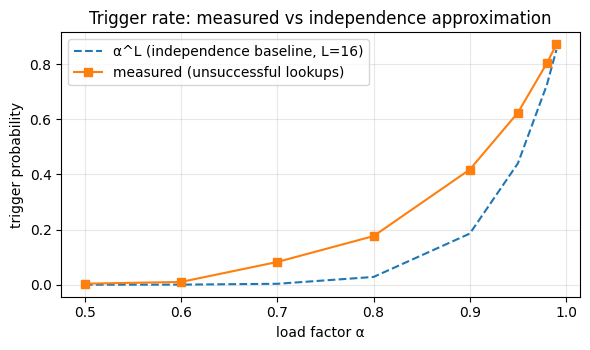

  α=0.50   α^16= 0.000   measured= 0.004
  α=0.60   α^16= 0.000   measured= 0.010
  α=0.70   α^16= 0.003   measured= 0.083
  α=0.80   α^16= 0.028   measured= 0.176
  α=0.90   α^16= 0.185   measured= 0.417
  α=0.95   α^16= 0.440   measured= 0.624
  α=0.98   α^16= 0.724   measured= 0.802
  α=0.99   α^16= 0.851   measured= 0.871


In [ ]:
import matplotlib.pyplot as plt

def miss_trigger_rate(loads, n=1 << 14, L=16, n_miss=800, seed=77):
    rates = []
    for a in loads:
        random.seed(seed)
        t = CTBGHashTable(n, L=L)
        for k in random.sample(range(1, 10**9), int(n * a)):
            t.insert(k, k)
        t.stats.reset()
        for k in random.sample(range(10**9, 2 * 10**9), n_miss):
            t.lookup(k)
        fb = t.stats.count("lookup_miss_fb")
        rates.append(fb / n_miss)
    return rates

loads_c = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99]
measured = miss_trigger_rate(loads_c)
plt.figure(figsize=(6, 3.6))
plt.plot(loads_c, [a ** 16 for a in loads_c], "--", label="α^L (independence baseline, L=16)")
plt.plot(loads_c, measured, "s-", label="measured (unsuccessful lookups)")
plt.xlabel("load factor α"); plt.ylabel("trigger probability"); plt.grid(alpha=.3); plt.legend()
plt.title("Trigger rate: measured vs independence approximation")
plt.tight_layout(); plt.show()
for a, m in zip(loads_c, measured):
    print(f"  α={a:.2f}   α^16={a**16:6.3f}   measured={m:6.3f}")

### Interpretation

- **Experiment A** shows flat probe averages while `n` grows 16-fold at fixed load: No meaningful dependence on n was observed over the tested range, which is consistent with the analytical fixed-budget result.
- **Experiment B**'s slope fits reproduce linear probing's textbook signature (miss exponent
  close to the theoretical 2; the hit exponent, noisier at these sample sizes, on the order
  of 1), which validates the measurement method; against that
  calibrated baseline, the proposed algorithm's curves grow far more slowly at high load.
  Over the tested workloads, most triggered operations were resolved within the staged fallback, producing substantially slower probe-count growth than linear probing. This is
  the graceful-degradation behaviour the Part 1 success criterion (ii) asks for, and the
  low-load region shows criterion (i): below the trigger threshold the two algorithms make
  essentially the same probes.
- **Experiment C** confirms the Part 1 caution about the α^L formula: the measured trigger
  rate exceeds the independence baseline at high load because linear-probing clustering makes
  neighbouring occupancy dependent. As stated in the in the report Part 1 (5.5), the formula is an independence baseline rather than a prediction; in these experiments it underestimated the measured trigger rate as clustering increased.


Complexity analysis conclusion time is `O(L) = O(1)` untriggered, `O(B) = O(1)` triggered under the fixed staged budget, `O(n)` worst case via the terminal stage; space is `O(n)`.

Across the tested high-load range, the measured average probe counts grew substantially more slowly than those of linear probing.

## 4. CPython-optimised implementation

The basic version is written for readability; this version applies CPython-specific
techniques while keeping the **probe mathematics bit-for-bit identical** (verified below by
comparing final slot layouts):

1. **Flat parallel arrays** (`keys[]`, `vals[]`) with an `is`-testable sentinel instead of a
   list of `(key, value)` tuples, which removes tuple allocation and unpacking per slot.
2. **`__slots__`** : removes the per-instance `__dict__`, making attribute access cheaper.
3. **Hoisting** attribute lookups *and bound methods* (`self.keys`, `self.stats.record`) into
   locals before hot loops : hoisting frequently accessed attributes into local variables reduces repeated attribute-lookup overhead in CPython.
4. **Inlined arithmetic**: the splitmix64 mixer is expanded in place, eliminating a Python
   function call per probe.
5. **Pre-expanded schedules**: the staged `(region, t)` step sequence is computed once at
   construction into a flat list, eliminating generator resumption and counter-dict overhead
   from every triggered operation.
6. **Power-of-two capacities** use a bitmask instead of `%` for the home position.

In [ ]:
_EMPTY = object()          # unique sentinel: cheaper to test with `is` than tuple unpacking
_M = (1 << 64) - 1
_A = 0x9E3779B97F4A7C15
_B = 0xBF58476D1CE4E5B9
_C = 0x94D049BB133111EB
_RI = 0xC2B2AE3D27D4EB4F
_RT = 0x165667B19E3779F9


class OptCTBGHashTable:
    __slots__ = ("n", "L", "keys", "vals", "count", "stats", "_mask",
                 "_ins_steps", "_qry_steps", "_starts", "_sizes")

    def __init__(self, capacity, L=16, c=1, s_max=6, stats=None):
        self.n = capacity
        self.L = L
        self.keys = [_EMPTY] * capacity          # parallel flat arrays instead of
        self.vals = [None] * capacity            # a list of (key, value) tuples
        self.count = 0
        self._mask = capacity - 1 if capacity & (capacity - 1) == 0 else 0
        self.stats = stats if stats is not None else ProbeStatistics()
        k = max(2, capacity.bit_length() - 4)
        part = RegionPartition(capacity, k)
        self._starts = [s for s, _ in part.bounds]
        self._sizes = [z for _, z in part.bounds]
        # Pre-expand both schedules into flat (region_index_0based, t) step lists,
        # removing all generator and counter overhead from the hot path.
        self._ins_steps = self._expand(InsertionSchedule(c, s_max).steps(k))
        self._qry_steps = self._expand(QuerySchedule(c, s_max).steps(k))

    @staticmethod
    def _expand(sched):
        steps, counters = [], {}
        for i, budget in sched:
            t = counters.get(i, 0)
            for _ in range(budget):
                steps.append((i - 1, t))
                t += 1
            counters[i] = t
        return steps

    def insert(self, key, value):
        keys = self.keys                          # hoist attribute lookups to locals
        vals = self.vals
        n = self.n
        record = self.stats.record                # hoist the bound method too
        hk = hash(key) & _M
        x = (hk + _A) & _M                        # inlined splitmix64 (no call per probe)
        x = ((x ^ (x >> 30)) * _B) & _M
        x = ((x ^ (x >> 27)) * _C) & _M
        x = (x ^ (x >> 31)) & _M
        m = self._mask
        home = (x & m) if m else (x % n)
        probes = 0
        for j in range(self.L):                   # Phase 1: bounded local window
            pos = home + j
            if pos >= n:
                pos -= n
            probes += 1
            s = keys[pos]
            if s is _EMPTY:
                keys[pos] = key
                vals[pos] = value
                self.count += 1
                record("insert_local", probes)
                return Outcome.OK
            if s == key:
                record("insert_dup", probes)
                return Outcome.DUPLICATE
        self.stats.triggers += 1                  # Trigger
        starts, sizes = self._starts, self._sizes
        for ri, t in self._ins_steps:             # Phase 2: pre-expanded staged walk
            x = (hk ^ ((ri + 1) * _RI) ^ (t * _RT)) & _M
            x = (x + _A) & _M
            x = ((x ^ (x >> 30)) * _B) & _M
            x = ((x ^ (x >> 27)) * _C) & _M
            pos = starts[ri] + ((x ^ (x >> 31)) & _M) % sizes[ri]
            probes += 1
            s = keys[pos]
            if s is _EMPTY:
                keys[pos] = key
                vals[pos] = value
                self.count += 1
                record("insert_fallback", probes)
                return Outcome.OK
            if s == key:
                record("insert_dup", probes)
                return Outcome.DUPLICATE
        for pos in range(n - 1, -1, -1):          # terminal stage
            probes += 1
            s = keys[pos]
            if s is _EMPTY:
                keys[pos] = key
                vals[pos] = value
                self.count += 1
                record("insert_fallback", probes)
                return Outcome.OK
            if s == key:
                record("insert_dup", probes)
                return Outcome.DUPLICATE
        record("insert_full", probes)
        return Outcome.FULL

    def lookup(self, key):
        keys = self.keys
        n = self.n
        record = self.stats.record
        hk = hash(key) & _M
        x = (hk + _A) & _M
        x = ((x ^ (x >> 30)) * _B) & _M
        x = ((x ^ (x >> 27)) * _C) & _M
        x = (x ^ (x >> 31)) & _M
        m = self._mask
        home = (x & m) if m else (x % n)
        probes = 0
        for j in range(self.L):                   # Phase 1
            pos = home + j
            if pos >= n:
                pos -= n
            probes += 1
            s = keys[pos]
            if s is _EMPTY:
                record("lookup_miss_local", probes)
                return Outcome.ABSENT
            if s == key:
                record("lookup_hit_local", probes)
                return Outcome.FOUND
        self.stats.triggers += 1                  # Trigger
        starts, sizes = self._starts, self._sizes
        ins_steps, qry_steps = self._ins_steps, self._qry_steps
        li, lq = len(ins_steps), len(qry_steps)
        a = b = 0
        while a < li or b < lq:                   # interleaved staged walk
            if a < li:
                ri, t = ins_steps[a]; a += 1
                x = (hk ^ ((ri + 1) * _RI) ^ (t * _RT)) & _M
                x = (x + _A) & _M
                x = ((x ^ (x >> 30)) * _B) & _M
                x = ((x ^ (x >> 27)) * _C) & _M
                pos = starts[ri] + ((x ^ (x >> 31)) & _M) % sizes[ri]
                probes += 1
                s = keys[pos]
                if s is _EMPTY:                   # empty on the insertion path
                    record("lookup_miss_fb", probes)
                    return Outcome.ABSENT
                if s == key:
                    record("lookup_hit_fb", probes)
                    return Outcome.FOUND
            if b < lq:
                ri, t = qry_steps[b]; b += 1
                x = (hk ^ ((ri + 1) * _RI) ^ (t * _RT)) & _M
                x = (x + _A) & _M
                x = ((x ^ (x >> 30)) * _B) & _M
                x = ((x ^ (x >> 27)) * _C) & _M
                pos = starts[ri] + ((x ^ (x >> 31)) & _M) % sizes[ri]
                probes += 1
                s = keys[pos]
                if s == key:
                    record("lookup_hit_fb", probes)
                    return Outcome.FOUND
        for pos in range(n - 1, -1, -1):          # terminal stage (insertion path)
            probes += 1
            s = keys[pos]
            if s is _EMPTY:
                record("lookup_miss_fb", probes)
                return Outcome.ABSENT
            if s == key:
                record("lookup_hit_fb", probes)
                return Outcome.FOUND
        record("lookup_miss_fb", probes)
        return Outcome.ABSENT

    @property
    def load(self):
        return self.count / self.n


In [ ]:
# behavioural equivalence: identical outcomes AND identical final slot layout
import random, time
random.seed(11)
n = 1 << 12
ks = random.sample(range(1, 10**9), int(n * 0.96))
basic, fast = CTBGHashTable(n), OptCTBGHashTable(n)
for k in ks:
    assert basic.insert(k, k) is fast.insert(k, k) is Outcome.OK
for k in random.sample(ks, 1500) + random.sample(range(10**9, 2 * 10**9), 1500):
    assert basic.lookup(k) is fast.lookup(k)
assert [(i, s[0]) for i, s in enumerate(basic.slots) if s] == \
       [(i, k) for i, k in enumerate(fast.keys) if k is not _EMPTY]
print("Equivalence verified: identical outcomes and identical slot-by-slot layout.\n")

# wall-clock benchmark
def bench(cls, n=1 << 15, load=0.9, n_lookups=40000, seed=3):
    random.seed(seed)
    ks = random.sample(range(1, 10**9), int(n * load))
    miss = random.sample(range(10**9, 2 * 10**9), n_lookups // 2)
    t = cls(n)
    t0 = time.perf_counter()
    for k in ks: t.insert(k, k)
    for k in ks[:n_lookups // 2]: t.lookup(k)
    for k in miss: t.lookup(k)
    return time.perf_counter() - t0

tb = min(bench(CTBGHashTable) for _ in range(3))
tf = min(bench(OptCTBGHashTable) for _ in range(3))
print(f"basic     : {tb:.3f} s")
print(f"optimised : {tf:.3f} s")
print(f"speedup   : x{tb / tf:.2f}")

Equivalence verified: identical outcomes and identical slot-by-slot layout.

basic     : 0.691 s
optimised : 0.474 s
speedup   : x1.46


**Why the speedup is bounded.** The gain (typically ~1.3–1.6× across runs) is real but limited, and the reason is
instructive: at moderate load the hot path is a handful of Phase-1 inspections, and in CPython
each inspection costs one bytecode-dispatch round trip regardless of how the surrounding code
is arranged. Once tuple unpacking, function calls and generator machinery are gone, the
interpreter itself is the remaining cost, which is precisely the argument (Part 1, 5.6) for
keeping the hot path in compiled code with contiguous storage. The two C++ versions below are
the natural continuation.

## 5. C++ implementation with OOP (reference text)

The class structure below is the one promised in Part 1 5.6: `CTBGHashTable` owning the slot
array, a `ProbeSchedule` strategy hierarchy for the two fallback orders, and a
`ProbeStatistics` collaborator. Deletions are not supported (for stability). C++17.

Code for the implementation can be found in below URL in github

[https://github.com/shandanjay/collision_triggered_bi-greedy_Probing/blob/main/ctbg.hpp](https://github.com/shandanjay/collision_triggered_bi-greedy_Probing/blob/main/ctbg.hpp)

## 6. Suggested optimised C++ implementation (reference text)

The optimised version keeps the same probe mathematics but restructures for the memory system
and the compiler, applying the plan from Part 1 5.6: **no virtual dispatch on the hot path**
(schedules become compile-time data), flat contiguous storage, a power-of-two capacity so `%`
becomes a mask, software prefetch of the home cache line, and branch-probability hints.
Instrumentation compiles away entirely when `Stats = NullStats`. Compile with
`-O3 -march=native` (add `-fno-exceptions` if the surrounding project allows it).

Code for the implementation can be found in below URL in github

[https://github.com/shandanjay/collision_triggered_bi-greedy_Probing/blob/main/ctbg_fast.hpp](https://github.com/shandanjay/collision_triggered_bi-greedy_Probing/blob/main/ctbg_fast.hpp)

**What changed relative to the OOP version, and why it matters on real hardware:** the
`ProbeSchedule` hierarchy is gone from the hot path (the output is plain
data built once in the constructor, so there is no virtual call per probe and the compiler has greater freedom to inline, unroll and optimise the loops.);

`L` is a template parameter, allowing the compiler to unroll the window scan where beneficial;

`key == 0` doubles as the empty test, removing the `occupied` flag and shrinking the slot
to 16 bytes so four slots share a 64-byte cache line, the `L = 16` window touches at most five lines;

This demonstration reserves key value 0 as the empty sentinel; a production implementation would require an alternative metadata representation or key encoding if zero is a valid key.

The power-of-two mask removes integer division from the home computation;

These are exactly the
measures Part 1 (5.6) planned: object-oriented structure at the boundaries, none of its costs
inside the inner loop.

## 7. Implications for the Real-World Problem

Part 1 posed a concrete operational problem: the spare capacity of low-load-factor tables represents a real memory cost, but increasing the load factor makes classical probing more expensive, both in average probe cost and, importantly, in the variability of that cost. The measurements in Part 2 can therefore be interpreted directly in terms of this space–time trade-off. Throughout the experiments, probe counts are used as a hardware-independent proxy for algorithmic work; the limitations of treating probes as a proxy for real execution time are considered at the end of this section.

For an idealised open-addressed slot array, the fraction of additional slot capacity relative to stored entries is

`1/α − 1`

where α is the load factor. At `α=0.50`, the table contains approximately 100% spare slot capacity relative to the number of stored entries. At `α=0.95`, this falls to approximately 5.3%, and at `α=0.99`, to approximately 1.0%. The practical attraction of operating near capacity is therefore clear: a sufficiently large in-memory structure can reclaim a substantial amount of otherwise reserved table space. The question is whether the additional collision cost required to obtain that memory saving remains acceptable.

Experiment B places this memory saving beside the corresponding probe cost. Linear probing becomes increasingly expensive as occupancy rises, with unsuccessful lookups showing the strongest deterioration. The proposed algorithm also incurs increasing work, but its measured probe counts grow substantially more slowly over the tested high-load range. This suggests that the collision-triggered fallback changes the shape of the trade-off: rather than forcing every operation to continue through an increasingly long local cluster, only operations whose bounded local window is exhausted enter the more complex fallback path.

In [ ]:
# Operating-point table: memory overhead joined to the Experiment B measurements
print(f"{'α':>5} | {'spare slots':>11} | {'LP miss':>8} | {'proposed miss':>13} | "
      f"{'LP hit':>7} | {'proposed hit':>12}")
for (a, li_ins, li_hit, li_mis), (_, ct_ins, ct_hit, ct_mis) in zip(lin, ctbg):
    over = (1 / a - 1) * 100
    print(f"{a:>5.2f} | {over:>10.1f}% | {li_mis:>8.1f} | {ct_mis:>13.1f} | "
          f"{li_hit:>7.2f} | {ct_hit:>12.2f}")



    α | spare slots |  LP miss | proposed miss |  LP hit | proposed hit
 0.50 |      100.0% |      2.6 |           2.6 |    1.57 |         1.57
 0.70 |       42.9% |      5.9 |           5.5 |    2.45 |         2.31
 0.80 |       25.0% |     14.3 |           9.3 |    3.20 |         2.86
 0.90 |       11.1% |     64.2 |          20.3 |    6.95 |         4.09
 0.95 |        5.3% |    312.8 |          40.6 |   18.27 |         6.11
 0.98 |        2.0% |   2384.1 |         123.0 |   32.99 |         4.59
 0.99 |        1.0% |   3169.5 |         318.5 |   26.98 |         5.36


In [ ]:
# One concrete, deliberately idealised scenario (slot array only)
entries, slot_bytes = 100_000_000, 16
for a in (0.50, 0.95, 0.99):
    gb = entries / a * slot_bytes / 1e9
    print(f"\n{entries/1e6:.0f}M entries at α={a:.2f}: "
          f"slot array ≈ {gb:5.2f} GB  (spare slots: {(1/a-1)*100:4.1f}%)")
save95 = (1 - (1/0.95) / (1/0.50)) * 100
print(f"\nMoving the operating point from α=0.50 to α=0.95 shrinks the idealised "
      f"slot array by ≈ {save95:.0f}%.")


100M entries at α=0.50: slot array ≈  3.20 GB  (spare slots: 100.0%)

100M entries at α=0.95: slot array ≈  1.68 GB  (spare slots:  5.3%)

100M entries at α=0.99: slot array ≈  1.62 GB  (spare slots:  1.0%)

Moving the operating point from α=0.50 to α=0.95 shrinks the idealised slot array by ≈ 47%.


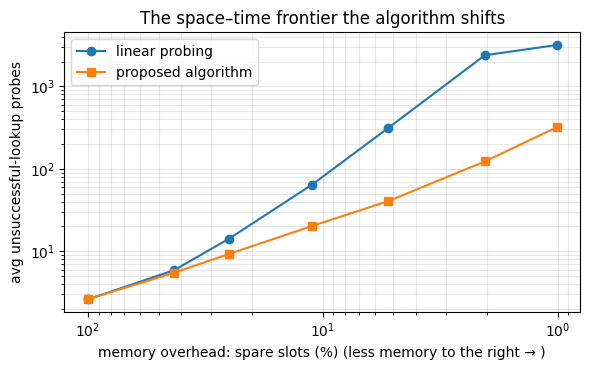

In [ ]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot([(1/a-1)*100 for a, *_ in lin],  [r[3] for r in lin],  "o-", label="linear probing")
ax.plot([(1/a-1)*100 for a, *_ in ctbg], [r[3] for r in ctbg], "s-", label="proposed algorithm")
ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis()
ax.set_xlabel("memory overhead: spare slots (%) (less memory to the right → )")
ax.set_ylabel("avg unsuccessful-lookup probes")
ax.set_title("The space–time frontier the algorithm shifts")
ax.grid(alpha=.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

Tail behaviour: the symptom the problem statement named

Part 1 (1.2) identified rising variability as the practical symptom of a table near capacity (service objectives are set on tails, not means). Averages can hide this entirely, so the cell below records per-operation probe counts and reports percentiles.

In [ ]:
import random

def per_op_probes(table_cls, n, load, n_hit=500, n_miss=500, seed=5, **kw):
    random.seed(seed)
    t = table_cls(n, **kw)
    keys = random.sample(range(1, 10**9), int(n * load))
    for k in keys:
        t.insert(k, k)
    hits, misses = [], []
    for k in random.sample(keys, n_hit):
        t.stats.reset(); t.lookup(k)
        hits.append(sum(t.stats._sum.values()))
    for k in random.sample(range(10**9, 2 * 10**9), n_miss):
        t.stats.reset(); t.lookup(k)
        misses.append(sum(t.stats._sum.values()))
    return sorted(hits), sorted(misses)

def pct(xs, q):
    return xs[min(len(xs) - 1, int(q * len(xs)))]


                       |   p50 |    p95 |    p99 |    max   (probes per lookup)
load α = 0.90
  linear probing  miss |    16 |    242 |    420 |    476
  proposed algo   miss |    11 |     63 |     91 |    113
  linear probing  hit  |     1 |     17 |    105 |    197
  proposed algo   hit  |     1 |     14 |     33 |     49
load α = 0.98
  linear probing  miss |   970 |   5948 |   6625 |   6805
  proposed algo   miss |   111 |    385 |    385 |    385
  linear probing  hit  |     2 |    120 |    841 |   2818
  proposed algo   hit  |     2 |     30 |    134 |    321


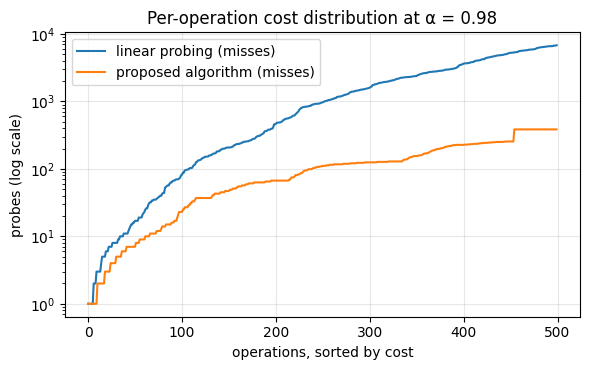

In [ ]:

print(f"{'':>22} | {'p50':>5} | {'p95':>6} | {'p99':>6} | {'max':>6}   (probes per lookup)")
for a in (0.90, 0.98):
    lp_h, lp_m = per_op_probes(LinearProbingTable, 1 << 14, a)
    ct_h, ct_m = per_op_probes(CTBGHashTable, 1 << 14, a, L=16)
    print(f"load α = {a:.2f}")
    for name, xs in (("linear probing  miss", lp_m), ("proposed algo   miss", ct_m),
                     ("linear probing  hit ", lp_h), ("proposed algo   hit ", ct_h)):
        print(f"{name:>22} | {pct(xs,.50):>5} | {pct(xs,.95):>6} | {pct(xs,.99):>6} | {xs[-1]:>6}")

import matplotlib.pyplot as plt
lp_h, lp_m = per_op_probes(LinearProbingTable, 1 << 14, 0.98)
ct_h, ct_m = per_op_probes(CTBGHashTable, 1 << 14, 0.98, L=16)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(range(len(lp_m)), lp_m, label="linear probing (misses)")
ax.plot(range(len(ct_m)), ct_m, label="proposed algorithm (misses)")
ax.set_yscale("log"); ax.set_xlabel("operations, sorted by cost")
ax.set_ylabel("probes (log scale)"); ax.grid(alpha=.3)
ax.set_title("Per-operation cost distribution at α = 0.98"); ax.legend()
plt.tight_layout(); plt.show()

The tail is where the two algorithms differ most: at α = 0.98 linear probing's worst
lookups run to thousands of probes (the longest cluster), while the proposed algorithm's are
capped near the staged budget (the sampled distribution exhibits a clear empirical ceiling near the staged budget, which is precisely the shape a
tail-latency objective needs). This is the empirical content behind Part 1's claim that the
fallback's value is *graceful* degradation, not a better average at low load.

### Skewed access: the workload shape real caches have

To explore a workload in which popularity is correlated with insertion order, the following experiment applies a bounded Zipf distribution over insertion rank. This represents a favourable scenario for the local phase because frequently queried keys were inserted while the table was relatively sparse. It should not be interpreted as a general property of all skewed cache workloads.

In [ ]:
import numpy as np
np.random.seed(4)
random.seed(4)
n, a = 1 << 14, 0.98
t = CTBGHashTable(n, L=16)
keys = random.sample(range(1, 10**9), int(n * a))
for k in keys:
    t.insert(k, k)

def avg_probes(sample):
    tot = 0
    for k in sample:
        t.stats.reset(); t.lookup(k)
        tot += sum(t.stats._sum.values())
    return tot / len(sample)

In [ ]:

# Bounded Zipf over insertion rank: P(rank r) ∝ r^(-1.2), popular = inserted early.
m = len(keys)
w = 1.0 / np.arange(1, m + 1) ** 1.2
w /= w.sum()
hot_share = w[: m // 10].sum()               # traffic share of the top 10% of keys
ranks = np.random.choice(m, size=3000, p=w)
zipf_sample = [keys[r] for r in ranks]
uniform_sample = [keys[i] for i in np.random.randint(0, m, 3000)]

u, z = avg_probes(uniform_sample), avg_probes(zipf_sample)
print(f"workload skew: top 10% of keys receive {hot_share:.0%} of lookups (Zipf s=1.2)")
print(f"avg successful-lookup probes at α={a:.2f} (proposed algorithm):")
print(f"  uniform access     : {u:6.2f}")
print(f"  Zipf-skewed access : {z:6.2f}   ({(1 - z / u) * 100:.0f}% fewer probes)")
print(f"  median insertion-time rank of Zipf lookups: {int(np.median(ranks))} of {m}")

workload skew: top 10% of keys receive 91% of lookups (Zipf s=1.2)
avg successful-lookup probes at α=0.98 (proposed algorithm):
  uniform access     :   6.74
  Zipf-skewed access :   1.14   (83% fewer probes)
  median insertion-time rank of Zipf lookups: 10 of 16056


### What this evidence does and does not show

Under the tested skewed workload, where popularity is deliberately correlated with early insertion, the experienced average is substantially lower than under uniform access. This is because traffic concentrates on the keys served by the cheap phase. The uniform-access results remain the neutral baseline; the skew experiment shows that some favourable real-world access distributions may reduce the experienced average further.

#### Limitations of the proxy

Transparency about the proxy is more important than the headline numbers. Three limitations should be noted:

1.   Probes are not nanoseconds.
2.   The memory arithmetic applies only to the idealised slot array.
3.   The demonstration is limited in scale.


These limitations do not invalidate the evidence, but they define how it should be interpreted. Probe counts are useful for comparing algorithmic behaviour, but they are not direct latency measurements because sequential and scattered probes have very different hardware costs. Similarly, the approximately 47% memory saving applies only to the simplified slot-array model, not to a full production key-value store with values, metadata and allocator overhead. Finally, the experiments use Python-scale tables, synthetic uniform keys, no deletions and a single thread, so they demonstrate the mechanism rather than production-scale performance.

Within these limits, the evidence supports the Part 1 relevance claim on its own terms. The algorithm moves the achievable operating point toward high load. More importantly, it controls the tail, where high-load open addressing is usually most vulnerable. Skewed real-world traffic strengthens this picture rather than weakening it, because it concentrates queries on the keys that the cheap phase serves most effectively.

## Summary

- The basic Python implementation translates the Part 1 pseudocode into working, tested code;
  differential testing against `dict` plus edge-case tests (duplicates in both phases, absence
  certificates in both phases, 100%-full termination, resize, stability) all pass.
- Complexity was determined three ways and the answers agree: analytically `O(1)` untriggered
  and `O(B)` triggered per operation with an `O(n)` worst case and `O(n)` space; empirically
  flat in `n` (doubling experiment) and far slower-growing in the load than linear probing
  (log–log slopes, with the baseline reproducing its textbook exponents as a control).
- The measured trigger rate confirms the report's caution that `α^L` is a floor, not a
  prediction, once clustering sets in.
- A CPython-optimised rewrite (flat arrays, `__slots__`, hoisted locals, inlined mixing,
  pre-expanded schedules, bitmasks) is bit-for-bit equivalent and ~1.3–1.6× faster; the remaining
  cost is interpreter dispatch itself, which motivates the two C++ reference implementations,
  an OOP version matching the class design promised in Part 1, and an optimised version that
  moves all abstraction out of the hot path.
- Read against the Part 1 problem, the measurements support the operating-point claim: the experiments show that operation at 0.95–0.99 load can retain substantially lower average and p99 probe counts than linear probing in the tested configurations, and that improve further under the skewed access real caches exhibit; converting probes into wall-clock latency on hardware is the stated next step, via the C++ implementations.

## 8. GenAI Usage

Generative AI, Google Gemini, was used as a supporting tool during the implementation, verification and optimisation stages of Part 2. For the complexity analysis, it was used to challenge and cross-check my manual Big-O reasoning and to explore suitable empirical methods for verifying the expected scaling behaviour. This contributed to the use of input-size doubling and log-log slope fitting as supporting experiments.

Gemini prompts were also used to explore and better understand implementation-level optimisation strategies beyond the basic Python implementation, in understanding of the CPython optimisation and C++ implementations, including why techniques such as flat storage, reduced abstraction on the hot path, pre-expanded schedules, bitmasks, compile-time constants and cache-conscious access patterns can be used to reduce implementation overhead. This assistance was used to interpret the optimisation choices and compare how the same algorithm behaves at different implementation levels, rather than to determine the core algorithm itself. The suggested optimisation ideas were reviewed and evaluated against the implemented behaviour before being included.

Finally, GenAI was used to investigate how the same algorithm could be represented more efficiently in C++, where hardware-level concerns such as contiguous slot layout, static rather than virtual dispatch on the hot path, compile-time constants, branch hints and software prefetching can be considered more directly. These C++ suggestions were treated as optimisation hypotheses rather than assumed improvements; their purpose was to demonstrate how the high-level Python simulation could translate into a systems-oriented implementation. All generated suggestions were reviewed against the algorithm's invariants and relevant documentation rather than incorporated automatically.

## 9. References

[1] M. Farach-Colton, A. Krapivin, and W. Kuszmaul, “Greedy Open Addressing Revisited: Beyond Yao’s Lower Bound,” in *Proc. 58th Annual ACM Symposium on Theory of Computing (STOC ’26)*, 2026, pp. 1116–1127, doi: 10.1145/3798129.3800823.

[2] D. E. Knuth, *The Art of Computer Programming, Vol. 3: Sorting and Searching*, 2nd ed. Reading, MA, USA: Addison-Wesley, 1998.

[3] G. L. Steele Jr., D. Lea, and C. H. Flood, “Fast Splittable Pseudorandom Number Generators,” *ACM SIGPLAN Notices*, vol. 49, no. 10, pp. 453–472, Oct. 2014, doi: 10.1145/2714064.2660195.

[4] B. Atikoglu, Y. Xu, E. Frachtenberg, S. Jiang, and M. Paleczny, “Workload Analysis of a Large-Scale Key-Value Store,” in *Proc. ACM SIGMETRICS/PERFORMANCE Joint International Conference on Measurement and Modeling of Computer Systems*, 2012, pp. 53–64, doi: 10.1145/2318857.2254766.

[5] Python Software Foundation, “time - Time access and conversions,” *Python 3 Documentation*. [Online]. Available: https://docs.python.org/3/library/time.html. [Accessed: Aug. 16, 2026].

[6] Python Software Foundation, “Data Model - `__slots__`,” *Python 3 Documentation*. [Online]. Available: https://docs.python.org/3/reference/datamodel.html. [Accessed: Aug. 16, 2026].

[7] Free Software Foundation, “Other Built-in Functions Provided by GCC,” *Using the GNU Compiler Collection (GCC)*. [Online]. Available: https://gcc.gnu.org/onlinedocs/gcc/Other-Builtins.html. [Accessed: Aug. 16, 2026].

[8] D. Jay, “Collision-Triggered Bi-Greedy Probing: Python and C++ Implementations,” GitHub repository, 2026. [Online]. Available: https://github.com/shandanjay/collision_triggered_bi-greedy_Probing. [Accessed: Aug. 16, 2026].

---


